## Data Preprocessing


In [2]:
import os

ambulance_count = len(os.listdir("ambulance_data/ambulance"))
non_ambulance_count = len(os.listdir("ambulance_data/non_ambulance"))
print("Ambulance:", ambulance_count)
print("Non-Ambulance:", non_ambulance_count)


Ambulance: 569
Non-Ambulance: 530


In [3]:
import cv2

img_shapes = []
bad_images = []

for category in ["ambulance", "non_ambulance"]:
    path = f"ambulance_data/{category}"
    for img_name in os.listdir(path):
        try:
            img = cv2.imread(os.path.join(path, img_name))
            shape = img.shape
            img_shapes.append(shape)
        except:
            bad_images.append(img_name)

# Show variety of shapes
unique_shapes = set(img_shapes)
print("Unique image sizes:", unique_shapes)
print("Corrupt or unreadable images:", len(bad_images))


Unique image sizes: {(225, 300, 3), (416, 416, 3), (519, 805, 3), (415, 700, 3), (4224, 5632, 3), (339, 542, 3), (330, 558, 3), (743, 1920, 3), (401, 600, 3), (360, 540, 3), (4096, 2304, 3), (800, 1080, 3), (1200, 1920, 3), (351, 626, 3), (422, 759, 3), (797, 1200, 3), (1024, 1024, 3), (3456, 4608, 3), (4032, 3024, 3), (399, 600, 3), (3968, 2976, 3), (847, 1280, 3), (194, 260, 3), (100, 100, 3), (1139, 1080, 3), (768, 1024, 3), (2322, 4128, 3), (1080, 1440, 3), (392, 600, 3), (5632, 4224, 3), (3168, 4752, 3), (2448, 3264, 3), (367, 468, 3), (1920, 2560, 3), (183, 276, 3), (310, 626, 3), (1068, 1600, 3), (309, 550, 3), (510, 827, 3), (4096, 3072, 3), (700, 1000, 3), (678, 1024, 3), (4160, 3120, 3), (4000, 2248, 3), (495, 660, 3), (382, 1008, 3), (4000, 1856, 3), (3456, 3456, 3), (3120, 4160, 3), (4000, 2250, 3), (376, 500, 3), (168, 300, 3), (558, 730, 3), (167, 303, 3), (594, 1056, 3), (175, 287, 3), (295, 420, 3), (159, 318, 3), (892, 1586, 3), (4608, 2128, 3), (253, 372, 3), (492, 80

# Try 3

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)  # EfficientNetB0 default, change if using B7
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    'ambulance_data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    'ambulance_data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 880 images belonging to 2 classes.
Found 219 images belonging to 2 classes.


In [3]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False  # For faster training (optional)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [5]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    'ambulance_data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    'ambulance_data',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)


Found 880 images belonging to 2 classes.
Found 219 images belonging to 2 classes.


In [6]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
11/28 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5482 - loss: 0.7080

c:\Users\Mridul\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


28/28 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.5197 - loss: 0.7162 - val_accuracy: 0.4840 - val_loss: 0.6949
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.4913 - loss: 0.7095 - val_accuracy: 0.4840 - val_loss: 0.7015
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5131 - loss: 0.7018 - val_accuracy: 0.4840 - val_loss: 0.6951
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.5231 - loss: 0.6932 - val_accuracy: 0.5160 - val_loss: 0.6921
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 120s 4s/step - accuracy: 0.5214 - loss: 0.6921 - val_accuracy: 0.5160 - val_loss: 0.6924
Epoch 6/10
20/28 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.5000 - loss: 0.6967

KeyboardInterrupt: 

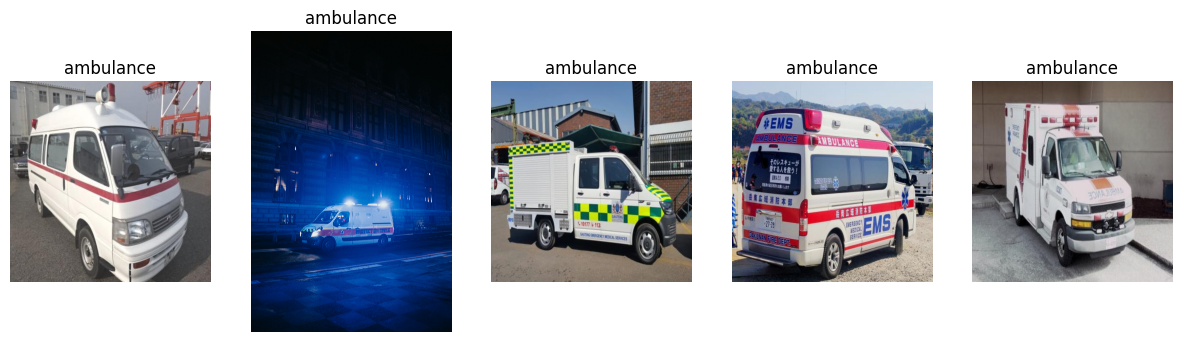

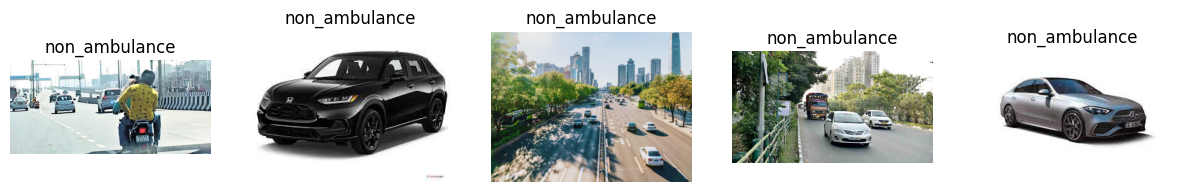

In [3]:
import matplotlib.pyplot as plt
import random

def show_random_images(category, n=5):
    folder = f"ambulance_data/{category}"
    images = random.sample(os.listdir(folder), n)
    
    plt.figure(figsize=(15,5))
    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')
    plt.show()

# Show sample images
show_random_images("ambulance")
show_random_images("non_ambulance")



In [4]:
def variance_of_laplacian(image):
    return cv2.Laplacian(image, cv2.CV_64F).var()

blurry_images = []

for category in ["ambulance", "non_ambulance"]:
    path = f"ambulance_data/{category}"
    for img_name in os.listdir(path):
        try:
            img = cv2.imread(os.path.join(path, img_name), 0)
            blur = variance_of_laplacian(img)
            if blur < 50:  # threshold (can adjust)
                blurry_images.append((category, img_name))
        except:
            continue

print("Total blurry images:", len(blurry_images))


Total blurry images: 5


In [6]:
import os
import cv2
from imutils import paths

def remove_blurry_images(folder, threshold=100):
    count = 0
    for imagePath in paths.list_images(folder):
        image = cv2.imread(imagePath)
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        if laplacian_var < threshold:
            os.remove(imagePath)
            count += 1
    print(f"Removed {count} blurry images from {folder}")

remove_blurry_images("ambulance_data/ambulance")
remove_blurry_images("ambulance_data/non_ambulance")


Removed 6 blurry images from ambulance_data/ambulance
Removed 18 blurry images from ambulance_data/non_ambulance


In [7]:
import os
from PIL import Image
from pathlib import Path

def resize_images(src_dir, dst_dir, size=(224, 224)):
    Path(dst_dir).mkdir(parents=True, exist_ok=True)
    for file in os.listdir(src_dir):
        src_path = os.path.join(src_dir, file)
        dst_path = os.path.join(dst_dir, file)

        try:
            img = Image.open(src_path)
            img = img.convert("RGB")
            img = img.resize(size)
            img.save(dst_path)
        except Exception as e:
            print(f"Error processing {file}: {e}")

resize_images("ambulance_data/ambulance", "processed_data/ambulance")
resize_images("ambulance_data/non_ambulance", "processed_data/non_ambulance")


c:\Users\Mridul\Desktop\Resume Projects\TrafficLightProject\venv\lib\site-packages\PIL\Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [8]:
import os
from PIL import Image

def check_shapes(folder):
    shapes = set()
    for img_file in os.listdir(folder):
        img = Image.open(os.path.join(folder, img_file))
        shapes.add(img.size)
    print(f"Unique shapes in {folder}: {shapes}")

check_shapes("processed_data/ambulance")
check_shapes("processed_data/non_ambulance")



Unique shapes in processed_data/ambulance: {(224, 224)}
Unique shapes in processed_data/non_ambulance: {(224, 224)}


In [12]:
import os
import random

folder_path = 'processed_data/non_ambulance'

# Step 1: Get all image files
image_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

# Step 2: Shuffle the list
random.shuffle(image_files)

# Step 3: Temporary renaming to avoid filename collisions
for i, old_name in enumerate(image_files):
    old_path = os.path.join(folder_path, old_name)
    temp_name = f"temp_{i}.jpg"
    temp_path = os.path.join(folder_path, temp_name)
    os.rename(old_path, temp_path)

# Step 4: Final renaming to new format: non_0000.jpg
temp_files = [f for f in os.listdir(folder_path) if f.startswith("temp_")]
for i, temp_name in enumerate(sorted(temp_files)):
    temp_path = os.path.join(folder_path, temp_name)
    final_name = f"non_{i:04d}.jpg"
    final_path = os.path.join(folder_path, final_name)
    os.rename(temp_path, final_path)

print(f"✅ Shuffled and renamed {len(image_files)} images successfully.")


✅ Shuffled and renamed 557 images successfully.


In [13]:
import os
import shutil
import random

def split_dataset_3way(source_dir, train_dir, val_dir, test_dir, train_ratio=0.7, val_ratio=0.15):
    categories = ['ambulance', 'non_ambulance']
    
    for category in categories:
        category_path = os.path.join(source_dir, category)
        images = os.listdir(category_path)
        random.shuffle(images)

        total = len(images)
        train_end = int(total * train_ratio)
        val_end = train_end + int(total * val_ratio)

        train_images = images[:train_end]
        val_images = images[train_end:val_end]
        test_images = images[val_end:]

        # Ensure directories exist
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(val_dir, category), exist_ok=True)
        os.makedirs(os.path.join(test_dir, category), exist_ok=True)

        # Copy files
        for img in train_images:
            shutil.copyfile(os.path.join(category_path, img), os.path.join(train_dir, category, img))

        for img in val_images:
            shutil.copyfile(os.path.join(category_path, img), os.path.join(val_dir, category, img))

        for img in test_images:
            shutil.copyfile(os.path.join(category_path, img), os.path.join(test_dir, category, img))

    print("✅ 3-way split complete.")

# Example usage:
split_dataset_3way(
    source_dir='processed_data',
    train_dir='split_data/train',
    val_dir='split_data/val',
    test_dir='split_data/test'
)


✅ 3-way split complete.


Found 787 images belonging to 2 classes.
Found 168 images belonging to 2 classes.
Found 171 images belonging to 2 classes.
16705208/16705208 [==============================] - 229s 14us/step
Epoch 1/10
25/25 [==============================] - 99s 3s/step - loss: 0.4873 - accuracy: 0.8170 - val_loss: 0.6990 - val_accuracy: 0.4940
Epoch 2/10
25/25 [==============================] - 79s 3s/step - loss: 0.1681 - accuracy: 0.9644 - val_loss: 0.7540 - val_accuracy: 0.4940
Epoch 3/10
25/25 [==============================] - 80s 3s/step - loss: 0.0824 - accuracy: 0.9784 - val_loss: 0.7935 - val_accuracy: 0.4940
Epoch 4/10
25/25 [==============================] - 78s 3s/step - loss: 0.0358 - accuracy: 0.9936 - val_loss: 0.8153 - val_accuracy: 0.4940
Epoch 5/10
25/25 [==============================] - 80s 3s/step - loss: 0.0275 - accuracy: 0.9924 - val_loss: 0.7724 - val_accuracy: 0.4940
Epoch 6/10
25/25 [==============================] - 81s 3s/step - loss: 0.0116 - accuracy: 0.9987 - val_loss:

c:\Users\Mridul\Desktop\Resume Projects\TrafficLightProject\ambulanceDetection\MyEnv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mridul\Desktop\Resume Projects\TrafficLightProject\ambulanceDetection\MyEnv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mridul\Desktop\Resume Projects\TrafficLightProject\ambulanceDetection\MyEnv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

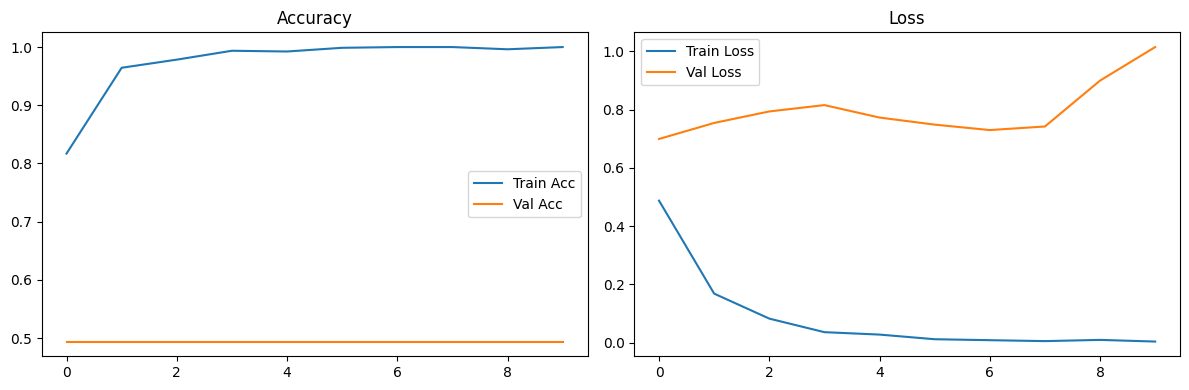

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Image dimensions
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'split_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    'split_data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    'split_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# Evaluate on test data
loss, acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

# Predictions
y_pred = (model.predict(test_generator) > 0.5).astype(int)
y_true = test_generator.classes

# Metrics
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Ambulance', 'Ambulance']))

print("\n🧮 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Optional: Plot accuracy & loss curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()
